# **Apex Planet Internship Task 3**

## **Deep-dive Analysis**

### **Loading data**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


# Load your cleaned dataset
df = pd.read_csv(r"C:\Users\Vinay\Downloads\Retail_Sales_cleaned_dataset.csv") # change filename if needed

# Check data
print(df.head()) 

  transaction_id customer_id       category          item  price_per_unit  \
0    Txn_6867343     Cust_09     Patisserie   Item_10_Pat            18.5   
1    Txn_3731986     Cust_22  Milk Products  Item_17_Milk            29.0   
2    Txn_9303719     Cust_02       Butchers   Item_12_But            21.5   
3    Txn_9458126     Cust_06      Beverages   Item_16_Bev            27.5   
4    Txn_4575373     Cust_05           Food   Item_6_Food            12.5   

   quantity  total_spent  payment_method location transaction_date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  discount_applied  transaction_date_year  transaction_date_month  \
0              NaN                   2024      

### **KPIs** 

In [7]:
# KPIs
total_revenue = df['total_spent'].sum()

avg_order_value = df['total_spent'].sum() / df['transaction_id'].count()

total_customers = df['customer_id'].nunique()

avg_quantity = df['quantity'].mean()

discount_impact = df.groupby('discount_applied')['total_spent'].mean()

print("Total Revenue:", total_revenue)
print("Avg Order Value:", avg_order_value)
print("Total Customers:", total_customers)
print("Avg Quantity:", avg_quantity)
print(discount_impact)

Total Revenue: 1614827.5
Avg Order Value: 128.41570576540755
Total Customers: 25
Avg Quantity: 5.558648111332008
discount_applied
Unknown    127.279948
Name: total_spent, dtype: float64


### **Deep-dive Analysis(Segmentation)**

  customer_id  total_spending  total_transactions     segment
0     Cust_01         61016.0                 507  High Value
1     Cust_02         64172.5                 488  High Value
2     Cust_03         62735.0                 465  High Value
3     Cust_04         63689.0                 474  High Value
4     Cust_05         69922.5                 544  High Value


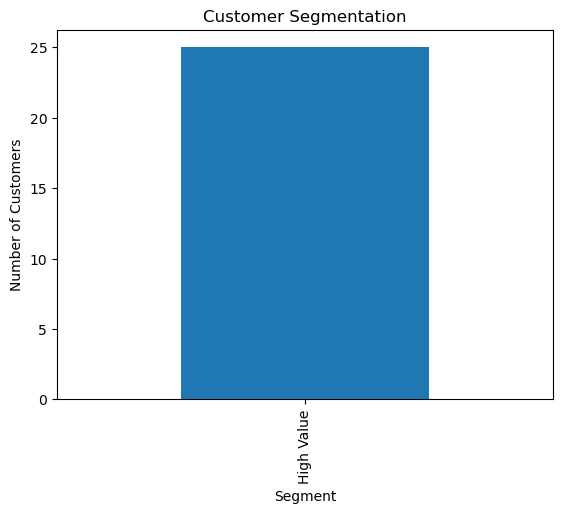

In [8]:
# STEP 3: Customer-level aggregation
customer_data = df.groupby('customer_id').agg({
    'total_spent': 'sum',
    'transaction_id': 'count'
}).reset_index()

# Rename columns
customer_data.rename(columns={
    'total_spent': 'total_spending',
    'transaction_id': 'total_transactions'
}, inplace=True)

# STEP 4: Segmentation logic
def segment(row):
    if row['total_spending'] > 5000:
        return 'High Value'
    elif row['total_spending'] > 2000:
        return 'Medium Value'
    else:
        return 'Low Value'

customer_data['segment'] = customer_data.apply(segment, axis=1)

# STEP 5: View result
print(customer_data.head())

# STEP 6: Visualization
customer_data['segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()
